In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# KCell — the core building block

`KCell` is kfactory's central class. Every component — from a simple rectangle to a
full photonic circuit — is a `KCell`. This page explains how to create cells, add
geometry, attach ports, and use the `@cell` decorator that makes parametric,
cache-efficient component functions easy to write.

## Setup: layers

Every notebook is self-contained and defines its own layers.
`LayerInfos` maps human-readable names to KLayout `LayerInfo` objects (layer number +
datatype). The global layout object `kf.kcl` is made aware of the new layer set so
that helper methods like `find_layer` work correctly.

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    CLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(4, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## Creating a cell manually

`kf.KCell()` returns a new, empty cell. You can add shapes to it using KLayout's
geometry API. Coordinates can be expressed in **database units (DBU)** or in
**micrometres (µm)**; kfactory re-exports both variants.

| Class | Coordinate unit | Typical suffix |
|-------|----------------|----------------|
| `kdb.Box` / `kdb.Polygon` | DBU (integers) | none |
| `kdb.DBox` / `kdb.DPolygon` | µm (floats) | `D` prefix |

The default DBU for `kf.kcl` is **1 nm** (i.e. `dbu = 0.001`), so 1 µm = 1000 DBU.

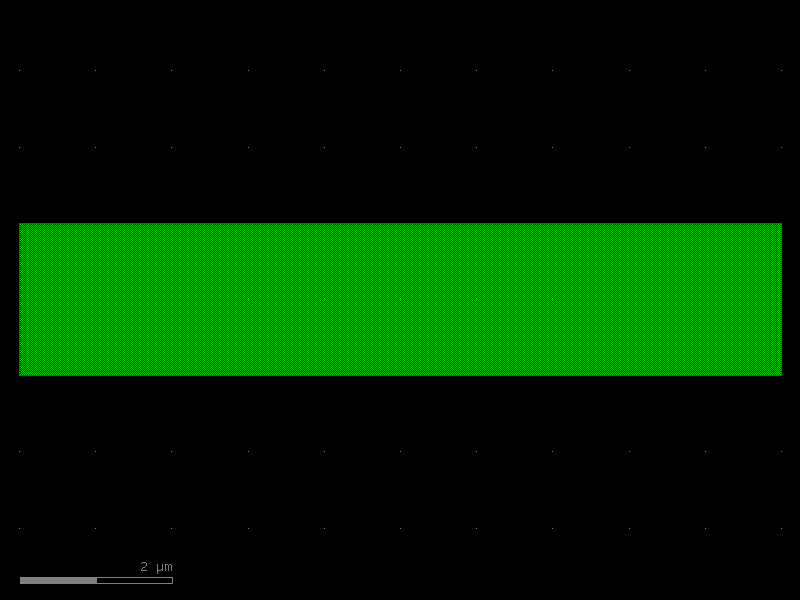

In [3]:
c = kf.KCell(name="my_rect")

# Add a 10 µm × 2 µm rectangle using µm coordinates (DBox)
c.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(-5, -1, 5, 1))

# Display in the notebook
c

### DBU vs µm

The same shape expressed in DBU:

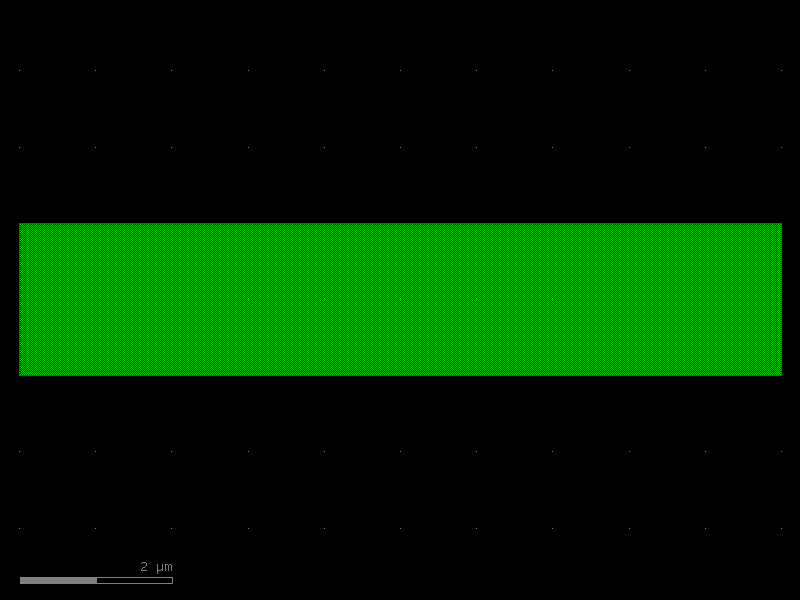

In [4]:
c_dbu = kf.KCell(name="my_rect_dbu")
# 10 µm = 10000 nm = 10000 DBU; 2 µm = 2000 DBU
c_dbu.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.Box(-5000, -1000, 5000, 1000))
c_dbu

Both cells are identical — choose whichever unit is most convenient. The `D`-prefixed
classes (`DBox`, `DPolygon`, …) accept floating-point µm values and are snapped to the
DBU grid automatically.

## Adding ports

Ports mark connection points on a cell. Each port has a position, width, orientation
(angle in degrees, 0° = east), and a layer. The convention is:

* `0°`  = east (right)
* `90°` = north (up)
* `180°` = west (left)
* `270°` = south (down)

Ports can be added in µm (`add_port`) or DBU coordinates (`add_port` with `dbu=True`
or by setting integer positions directly).

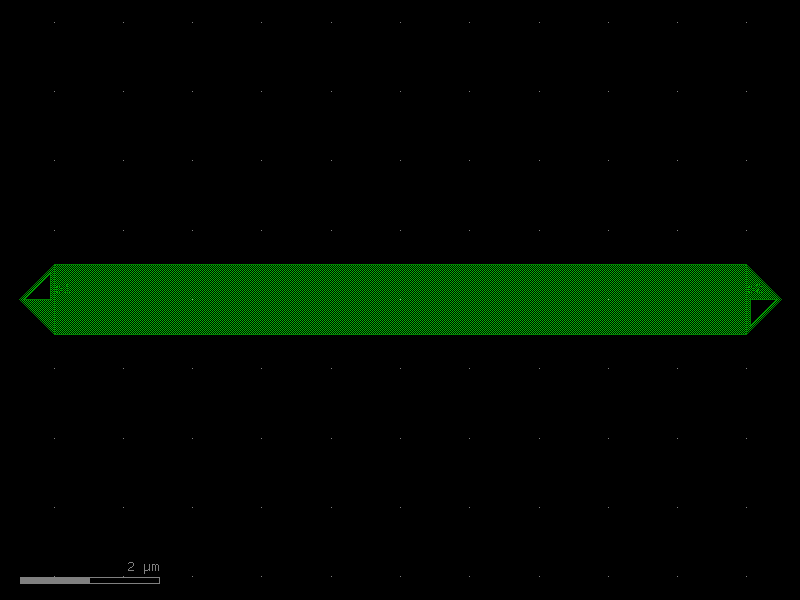

In [5]:
wg = kf.KCell(name="wg_with_ports")
wg.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(-5, -0.5, 5, 0.5))

# Left port: facing west (180°), centre at (-5, 0), width 1 µm
wg.add_port(
    port=kf.Port(
        name="o1",
        width=kf.kcl.to_dbu(1.0),
        dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, -5, 0),
        layer=kf.kcl.find_layer(L.WG),
        kcl=kf.kcl,
    )
)
# Right port: facing east (0°)
wg.add_port(
    port=kf.Port(
        name="o2",
        width=kf.kcl.to_dbu(1.0),
        dcplx_trans=kf.kdb.DCplxTrans(1, 0, False, 5, 0),
        layer=kf.kcl.find_layer(L.WG),
        kcl=kf.kcl,
    )
)

wg.draw_ports()
wg

## The `@cell` decorator — parametric cells with automatic caching

Writing a function that creates a `KCell` and decorating it with `@kf.cell` gives you:

1. **Automatic cell naming** — the cell name is derived from the function name and its
   parameter values, so every unique combination gets a unique GDS cell name.
2. **Result caching** — calling the function a second time with the same arguments
   returns the *same* `KCell` object without re-running the function body.
3. **Settings storage** — the parameter values are stored in `cell.settings` for
   traceability and serialisation.

This is the recommended way to create any reusable, parametric component.

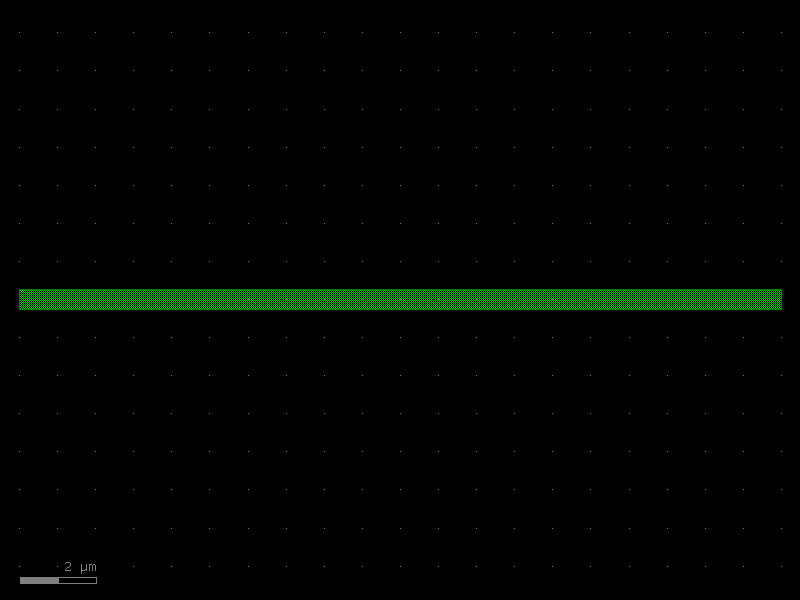

In [6]:
@kf.cell
def straight(
    length: float = 10.0,
    width: float = 1.0,
    layer: kf.kdb.LayerInfo = L.WG,
) -> kf.KCell:
    """A simple straight waveguide.

    Args:
        length: Length in µm.
        width: Width in µm.
        layer: Layer for the waveguide core.
    """
    c = kf.KCell()
    hw = width / 2
    c.shapes(kf.kcl.find_layer(layer)).insert(kf.kdb.DBox(0, -hw, length, hw))
    c.add_port(
        port=kf.Port(
            name="o1",
            width=kf.kcl.to_dbu(width),
            dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, 0, 0),
            layer=kf.kcl.find_layer(layer),
            kcl=kf.kcl,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            width=kf.kcl.to_dbu(width),
            dcplx_trans=kf.kdb.DCplxTrans(1, 0, False, length, 0),
            layer=kf.kcl.find_layer(layer),
            kcl=kf.kcl,
        )
    )
    return c


s = straight(length=20, width=0.5)
s

### Cell name encodes parameters

In [7]:
print(s.name)

straight_L20_W0p5_LWG


### Caching: same arguments → same object

In [8]:
s2 = straight(length=20, width=0.5)
print(f"Same object: {s is s2}")

s3 = straight(length=30, width=0.5)
print(f"Different length → different object: {s is s3}")
print(f"Different name: {s3.name}")

Same object: True
Different length → different object: False
Different name: straight_L30_W0p5_LWG


### Inspecting settings

In [9]:
s.settings

KCellSettings(length=20, width=0.5, layer=WG (1/0))

`settings` stores the resolved parameter values. This is useful when generating
netlists or reproducing a layout from metadata alone.

## Instances: placing cells inside other cells

Use the `<<` operator (or `create_inst`) to place one cell inside another.
An instance is a *pointer* — the underlying geometry is stored once; instances just
carry position/rotation transforms.

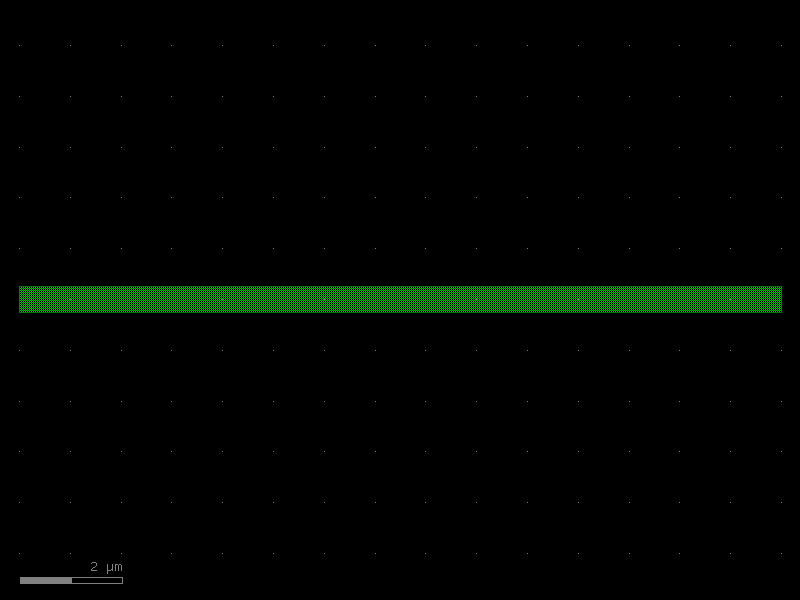

In [10]:
circuit = kf.KCell(name="two_waveguides")

wg_a = circuit << straight(length=15, width=0.5)
wg_b = circuit << straight(length=15, width=0.5)

# Place wg_b 5 µm above wg_a
wg_b.transform(kf.kdb.DTrans(0, 5))

circuit.add_ports(wg_a.ports, prefix="top_")
circuit.add_ports(wg_b.ports, prefix="bot_")
circuit

### Port-based connection with `connect`

`instance.connect("port_name", other_instance, "other_port_name")` moves and rotates
`instance` so that the named port aligns with the other port face-to-face.

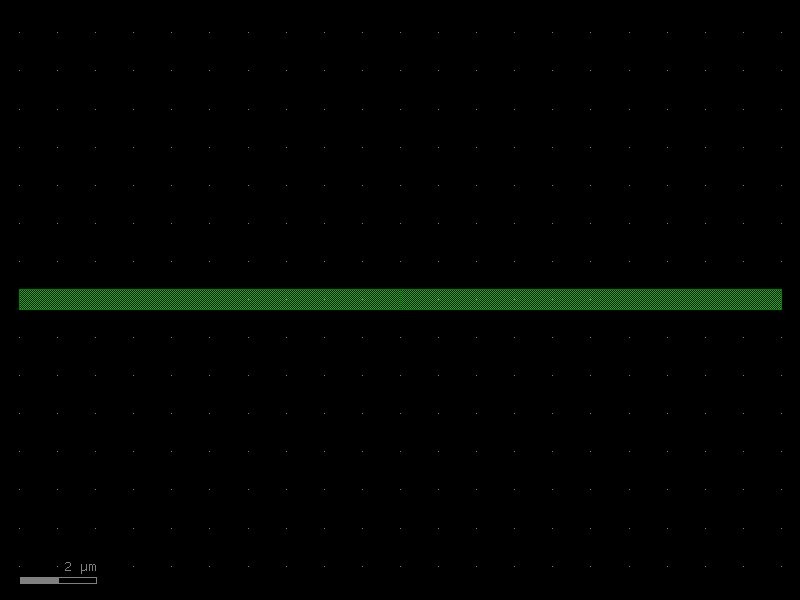

In [11]:
line = kf.KCell(name="connected_waveguides")
seg1 = line << straight(length=10, width=0.5)
seg2 = line << straight(length=10, width=0.5)
seg2.connect("o1", seg1.ports["o2"])

line.add_ports(seg1.ports, prefix="seg1_")
line.add_ports(seg2.ports, prefix="seg2_")
line

## KCell variants

kfactory ships three cell variants that differ in how geometry is stored:

| Class | Geometry storage | Typical use |
|-------|-----------------|-------------|
| `KCell` | KLayout database (DBU integers) | Standard physical components |
| `DKCell` | DBU integers, but DBU-aware µm API | Same as KCell, µm-native convenience |
| `VKCell` | In-memory only, never committed to the layout DB | Intermediate / throw-away geometry |

Use `VKCell` (and the matching `@vcell` decorator) when you need a temporary cell that
should not pollute the global cell namespace, for example as a scratch pad during
routing or in tests.

<class 'kfactory.kcell.VKCell'>


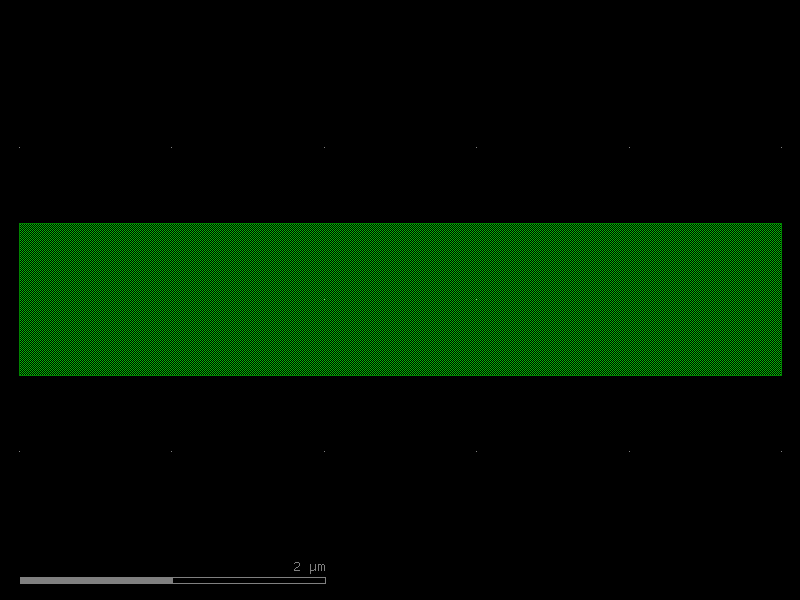

In [12]:
@kf.vcell
def virtual_scratch_pad(width: float = 2.0) -> kf.VKCell:
    """A virtual cell — not registered in the layout database."""
    vc = kf.VKCell()
    vc.shapes(kf.kcl.find_layer(L.WG)).insert(kf.kdb.DBox(0, -width / 2, 5, width / 2))
    return vc


vpad = virtual_scratch_pad(width=1.0)
print(type(vpad))
# VKCells render the same way in notebooks
vpad

## See Also

| Topic | Where |
|-------|-------|
| Port system (position, direction, type) | [Core Concepts: Ports](ports.py) |
| Placing and connecting instances | [Core Concepts: Instances](instances.py) |
| DBU vs µm coordinate systems | [Core Concepts: DBU vs µm](dbu_vs_um.py) |
| PCells and caching | [Components: PCells](../components/cells/pcells.py) |
| Virtual cells for routing | [Components: Virtual Cells](../components/cells/virtual.py) |